 ## Short-Time Fourier Transform  
 In this part, you will be implementing the short-time Fourier transform (STFT) and instanta
neous frequency to change the pitch of audio files. Use the same audio clips as we had in HW 2:
 (winniethepooh.wav) and (bach.wav), available from the class webpage.

## Question 1:

Write a Python function to compute the short-time Fourier transform (STFT) of a signal. Your function should take the following inputs: a signal $x[n]$, a window $w[n]$, and the hop length, $h$. It should output the STFT $X[k,m]$. Note: the length of your Fourier transform will be determined by the length of the $w[n]$array.

## Answer:

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import wave
from IPython.display import Audio

#x is input signal
#w is window function
#h is hop length
def stft(x, w, h):
    #Calculate necessary parameters and init variables
    
    L = len(x)  # Total number of samples in the signal x
    W = len(w)  # Window length (which also sets the DFT/FFT size)
    
    #Calculate the number of frequency bins (K, rows)
    K = int(np.floor(W / 2)) + 1 
    
    #Calculate the total number of frames (M, columns)
    M = int(np.floor((L - W) / h)) + 1
 
    #The output matrix X has dimensions K (frequency) by M (time)
    X = np.zeros((K, M), dtype=complex)

    #Begin to loop over the number of frames (time bins)
    for m in range(M):
        #Calculate the starting index for the current frame
        start_index = m * h
        
        #Calculate the ending index
        end_index = start_index + W
        
        #Extract the signal clip
        x_clip = x[start_index:end_index]
        
        #Apply the window function
        windowed_clip = x_clip * w
        
        #Compute FFT of the windowed clip
        fft_result = np.fft.fft(windowed_clip)
        
        #Store only the required K frequency bins (the first half) 
        #as the m-th column in the output matrix X 
        X[:, m] = fft_result[:K]
        
    return X

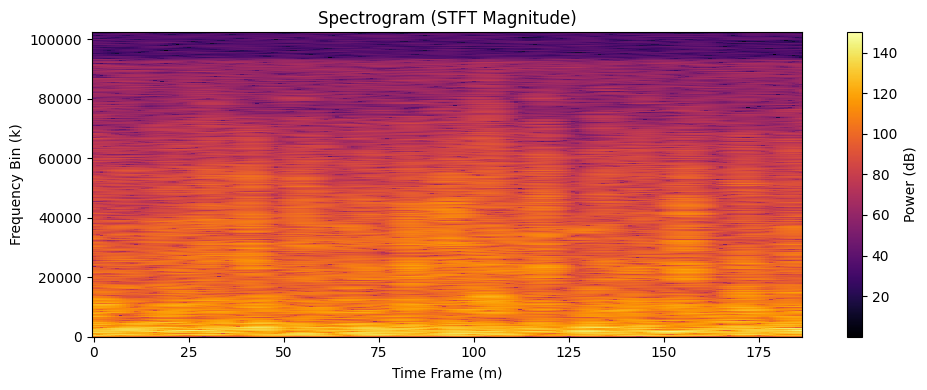

In [21]:
window = np.hanning(204800)
result = stft(voice_signal, window, 10240)
power_spectrogram = np.abs(result)**2 
power_spectrogram_db = 10 * np.log10(power_spectrogram + 1e-10)

plt.figure(figsize=(10, 4))
plt.imshow(np.abs(power_spectrogram_db), 
           aspect='auto', 
           origin='lower', 
           interpolation='none',
           cmap='inferno')

# Add labels and title
plt.title('Spectrogram (STFT Magnitude)')
plt.xlabel('Time Frame (m)')
plt.ylabel('Frequency Bin (k)')
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()

## Question 2:

Write a Python function implementing the overlap-add (OLA) method to synthesize a signal from its STFT. Your function should take the following inputs: an STFT, $X[k,m]$, a window, $w[n]$, and the hop length, h. It should output the synthesized signal, $x[n]$.

## Answer:

## Question 3: 
Do the following for both the voice and piano audio signals:

(a) Apply your forward STFT with a Hann window of length 2048 and a hop of 1024 tme samples. Now apply the OLA with a constant window of length 2048 and a hop of length 1024. Do you recover the original audio signals?


In [16]:
# This code reads in the wav file as a numpy array
voice_file = wave.open("winniethepooh.wav")
L_voice = voice_file.getnframes()
print("L_voice=",L_voice)
voice_signal = np.frombuffer(voice_file.readframes(L_voice), dtype = np.int16)

# Converting the signal values to float for better numerical processing
voice_signal = voice_signal.astype(float)

# The frame rate, or sampling rate, in Hz
fs_voice = voice_file.getframerate()
print("Voice fs=", fs_voice)

L_voice= 2116800
Voice fs= 44100


In [17]:
# This code reads in the wav file as a numpy array
bach_file = wave.open("bach.wav")
L_bach = bach_file.getnframes()
print("L_bach=",L_bach)
bach_signal = np.frombuffer(bach_file.readframes(L_bach), dtype = np.int16)

# Converting the signal values to float for better numerical processing
bach_signal = bach_signal.astype(float)

# The frame rate, or sampling rate, in Hz
fs_bach = bach_file.getframerate()
print("fs_bach=", fs_bach)

L_bach= 794304
fs_bach= 44100


(b) Repeat the process in part (a), but change the hop length to be the same as the window length, 2048. What changes do you notice in the resynthesized audio, and why did this happen?  

(c) Take the STFT with a square-root Hann window of length 1024 and a hop of 256. Next, set the resulting phase for each element of X to zero, i.e., create an array of only
 the magnitudes: $Y [k,m]$ = $|X[k,m]|$. Now apply the OLA with the same square-root Hann window and hop. What did this do to the audio? Explain why removing the phase
 had this effect.

## Answer:

## Question 4:

 Write a Python function to compute the exact frequency of a signal using backward differences of the phase of the STFT. Your function should compute a vector of exact frequencies (one for each frequency bin in the FFT) at all times $1 ≤ m < H$, in other words, the 2D array $ω∗[k,m]$ from the lecture. Create a sinusoid signal of length L = 256 and frequency $\frac{\sqrt{2π}}{8}$ . Test ryour function on this signal using a square-root Hann window of length 32 and hop of 16. Plot a spectrogram (squared magnitude $|X[k,m]|^2)$as an image. You should see a band
 of energy surrounding the exact frequency. Verify that your exact frequency function returns a value close to true frequency of the sinusoid

## Question 5:

. Write a Python function to perform pitch scaling. Test your algorithm on both the voice and piano audio with pitch scale factors of 2.0 and 0.5. Use 2048 square-root Hann windows for both STFT and OLA and hops of 512. (Not required, but feel free to experiment with different windows, hops, and scale factors. If you want to play with transposing the key in which the piano piece is played, use a scale factor of 2 k 12, where the integer k represents the
 number of half-notes up (positive) or down (negative) from the original key. For example, to change the key to a higher C minor, set k = 3, for a lower G minor, set k = −2.)

In [ ]:
m = 

# For Grads Only (or Extra Credit for Undergrads)

# Question 6:

 Use your pitch scaling function from the last part to change the speed of the two audio signals, while keeping the original pitch intact. Do this by scaling the pitch and also appropriately changing the sampling rate when playing back the audio. (Hint: Try doubling the sample rate when playing back the audio. What happens to the pitch? Now think about how you need to scale the frequency to return to the original pitch, but keeping the playback speed at
 double the rate.) Try speeds of 0.5, 0.75, 1.5, and 2.0 times the original.